# C. Sellers & Delivery Logistics

Things done in this category:
1. Loading `sellers_dataset.csv`, `geolocation_dataset.csv`, `order_items_dataset.csv`, and Category A's `orders_master.csv`
2. Cleaning and deduplicating geolocation, and building `geolocation_agg.csv`
3. Building `sellers_master.csv` : with seller level delivery performance + geography
4. Exploring delivery timing, seller size, and state level patterns
5. Flagging data quality issues and small sample size cautions found along the way
6. Detailed logistics analysis

In [1]:
import pandas as pd
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', None)

## 1. Load raw data

In [2]:
sellers = pd.read_csv('sellers_dataset.csv')
geo = pd.read_csv('geolocation_dataset.csv')
items = pd.read_csv('order_items_dataset.csv')

orders_master = pd.read_csv('orders_master.csv')

print("sellers shape:", sellers.shape)
print("geolocation shape:", geo.shape)

sellers shape: (3095, 4)
geolocation shape: (1000163, 5)


In [3]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [4]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


## 2. Initial data quality checks

In [5]:
print("Nulls in sellers:")
print(sellers.isnull().sum())
print("\nDistinct seller zip prefixes:", sellers['seller_zip_code_prefix'].nunique())
print("Distinct seller states:", sellers['seller_state'].nunique())

Nulls in sellers:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Distinct seller zip prefixes: 2246
Distinct seller states: 23


In [6]:
print("Nulls in geolocation:")
print(geo.isnull().sum())
print("\nDuplicate rows:", geo.duplicated().sum())
print("Distinct zip prefixes:", geo['geolocation_zip_code_prefix'].nunique(), "vs total rows:", geo.shape[0])

Nulls in geolocation:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Duplicate rows: 261831
Distinct zip prefixes: 19015 vs total rows: 1000163


**Finding:** This confirms that there are many lat/lng pairs per zip prefix which needs aggregation before use.

In [7]:
print("Lat range:", geo['geolocation_lat'].min(), "to", geo['geolocation_lat'].max())
print("Lng range:", geo['geolocation_lng'].min(), "to", geo['geolocation_lng'].max())

outliers = geo[(geo['geolocation_lat'] > 6) | (geo['geolocation_lat'] < -35) |
               (geo['geolocation_lng'] > -30) | (geo['geolocation_lng'] < -75)]
print("\nRows outside the possible Brazil area:", len(outliers))


Lat range: -36.6053744107061 to 45.06593318269697
Lng range: -101.46676644931476 to 121.10539381057764

Rows outside the possible Brazil area: 29


**Finding:** 29 geolocation rows have coordinates clearly outside Brazil (likely data entry errors
misplaced decimal or sign flip). Small enough to drop before aggregating, rather than letting them
distort the median.

In [9]:
stds = geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].std()

print("Distribution of lat std across all zip prefixes:\n")
print(stds['geolocation_lat'].describe())

loose_5km = (stds['geolocation_lat'] > 0.05).sum()
loose_50km = (stds['geolocation_lat'] > 0.5).sum()
print(f"\nZip prefixes with lat std > 0.05 (~5km spread): {loose_5km} / {len(stds)} ({100*loose_5km/len(stds):.1f}%)")
print(f"Zip prefixes with lat std > 0.5 (~50km spread, likely bad data): {loose_50km} / {len(stds)} ({100*loose_50km/len(stds):.1f}%)")


Distribution of lat std across all zip prefixes:

count    17972.000000
mean         0.055176
std          0.877860
min          0.000000
25%          0.002159
50%          0.004167
75%          0.009107
max         41.951323
Name: geolocation_lat, dtype: float64

Zip prefixes with lat std > 0.05 (~5km spread): 689 / 19015 (3.6%)
Zip prefixes with lat std > 0.5 (~50km spread, likely bad data): 170 / 19015 (0.9%)


**Limitation:** the median zip prefix is tightly clustered
(median std around 0.004°, which is a few hundred meters) but that's not universal. Because about 3.6% of zip prefixes have real spread beyond 5km, and 0.9% are spread wildly (tens of km or more, which is likely bad data rather than genuine geography).

**Decision:** Accepting this rather than building a more precise per state bounding box filter.

- A more precise version would need bounding boxes for all 27 states plus handling for non rectangular state borders which is more effort for not that great payoff, since a rural zip prefix can legitimately cover a much larger physical area than an urban one (so some of this spread is real, not an error).

- So instead, keeping the current rough Brazil wide filter (which catches the clearly impossible points), and treat visually inspecting the points
on an actual map, which will act as the real validation step because bad points will be obvious on a rendered map in a way a numeric threshold can't fully replace anyway.


## 3. Build `geolocation_agg.csv` (priority since Track D depends on this)
Deduplicate down to one row per zip prefix: median lat/lng (robust to the occasional bad point), most common city/state.

In [10]:
geo_clean = geo[(geo['geolocation_lat'] <= 6) & (geo['geolocation_lat'] >= -35) &
                (geo['geolocation_lng'] <= -30) & (geo['geolocation_lng'] >= -75)].copy()
print("Dropped as out of bounds:", len(geo) - len(geo_clean))

def mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]

geo_agg = geo_clean.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'median'),
    lng=('geolocation_lng', 'median'),
    city=('geolocation_city', mode_or_first),
    state=('geolocation_state', mode_or_first)
).reset_index().rename(columns={'geolocation_zip_code_prefix': 'zip_code_prefix'})

print("Shape:", geo_agg.shape)
geo_agg.head()

Dropped as out of bounds: 29
Shape: (19011, 5)


,zip_code_prefix,lat,lng,city,state
0,1001,-23.550381,-46.634027,sao paulo,SP
1,1002,-23.548551,-46.635072,sao paulo,SP
2,1003,-23.548977,-46.635313,sao paulo,SP
3,1004,-23.549535,-46.634771,sao paulo,SP
4,1005,-23.549612,-46.636532,sao paulo,SP


In [11]:
geo_agg.to_csv('geolocation_agg.csv', index=False)
print("Saved geolocation_agg.csv:", geo_agg.shape)

Saved geolocation_agg.csv: (19011, 5)


## 4. Build `sellers_master.csv`
Join sellers to their zip's coordinates, then aggregate order/delivery performance per seller from
`order_items` with Category A's `orders_master.csv`.

In [12]:
sellers_geo = sellers.merge(geo_agg, left_on='seller_zip_code_prefix', right_on='zip_code_prefix', how='left')
print("Sellers with no lat/lng match:", sellers_geo['lat'].isnull().sum())
sellers_geo[sellers_geo['lat'].isnull()][['seller_id','seller_zip_code_prefix','seller_city','seller_state']]

Sellers with no lat/lng match: 7


,seller_id,seller_zip_code_prefix,seller_city,seller_state
473,5962468f885ea01a1b6a97a218797b0a,82040,curitiba,PR
791,2aafae69bf4c41fbd94053d9413e87ee,91901,porto alegre,RS
1672,2a50b7ee5aebecc6fd0ff9784a4747d6,72580,brasilia,DF
1931,2e90cb1677d35cfe24eef47d441b7c87,2285,sao paulo,SP
2182,0b3f27369a4d8df98f7eb91077e438ac,7412,aruja,SP
2986,42bde9fef835393bb8a8849cb6b7f245,71551,brasilia,DF
3028,870d0118f7a9d85960f29ad89d5d989a,37708,pocos de caldas,MG


**Finding:** 7 seller zip prefixes have no matching entry anywhere in the geolocation table at all.
Kept as null lat/lng (documented, not dropped) so these sellers will not plot on a map.

In [13]:
items_orders = items[['order_id', 'seller_id']].drop_duplicates().merge(
    orders_master[['order_id', 'delivery_days', 'delivery_delay_days', 'is_late', 'is_delivered']],
    on='order_id', how='left'
)

seller_perf = items_orders.groupby('seller_id').agg(
    n_orders=('order_id', 'nunique'),
    avg_delivery_days=('delivery_days', 'mean'),
    pct_late=('is_late', 'mean'),
).reset_index()

freight_agg = items.groupby('seller_id')['freight_value'].mean().reset_index().rename(columns={'freight_value': 'avg_freight_value'})
seller_perf = seller_perf.merge(freight_agg, on='seller_id', how='left')

sellers_master = sellers_geo[['seller_id', 'seller_city', 'seller_state', 'lat', 'lng']].merge(
    seller_perf, on='seller_id', how='left'
)

sellers_master['low_confidence'] = sellers_master['n_orders'] < 5

print("Shape:", sellers_master.shape)
print("Sellers with no matching order_items at all:", sellers_master['n_orders'].isnull().sum())
print("Sellers flagged low_confidence (n_orders < 5):", sellers_master['low_confidence'].sum(), "/", len(sellers_master))
sellers_master.head()

Shape: (3095, 10)
Sellers with no matching order_items at all: 0
Sellers flagged low_confidence (n_orders < 5): 1301 / 3095


,seller_id,seller_city,seller_state,lat,lng,n_orders,avg_delivery_days,pct_late,avg_freight_value,low_confidence
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP,-22.894561,-47.062380,3,13.018588,0.333333,9.300000,True
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP,-22.382440,-46.947605,40,9.191988,0.050000,35.090976,False
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ,-22.909624,-43.176774,1,4.042292,0.000000,16.210000,True
3,c0f3eea2e14555b6faeea3dd58c1b1c3,sao paulo,SP,-23.657453,-46.612406,1,5.667187,0.000000,15.660000,True
4,51a04a8a6bdcb23deccc82b0b80742cf,braganca paulista,SP,-22.964436,-46.535090,1,35.314861,1.000000,31.930000,True


In [15]:
sellers_master.to_csv('sellers_master.csv', index=False)
print("Saved sellers_master.csv:", sellers_master.shape)

Saved sellers_master.csv: (3095, 10)


## 5. Exploratory analysis : seller & geographic patterns

In [16]:
print("pct_late distribution across sellers")
print(sellers_master['pct_late'].describe())

pct_late distribution across sellers
count    3095.000000
mean        0.076464
std         0.155489
min         0.000000
25%         0.000000
50%         0.000000
75%         0.095238
max         1.000000
Name: pct_late, dtype: float64


In [17]:
print("n_orders distribution (seller size)")
print(sellers_master['n_orders'].describe())

n_orders distribution (seller size)
count    3095.000000
mean       32.313409
std       105.139763
min         1.000000
25%         2.000000
50%         6.000000
75%        21.500000
max      1854.000000
Name: n_orders, dtype: float64


**Finding:** median seller has only 6 total orders, and the 25th
percentile is just 2. So a seller showing 0% late may simply not have had enough orders for a late delivery to occur yet, not necessarily a good service.

- Any chart ranking best/worst sellers by `pct_late` should keep this in mind (e.g. only compare sellers above a minimum order count threshold,
or size dot/marker area by `n_orders` so low confidence points are visually de emphasized).

In [18]:
sellers_master['size_bucket'] = pd.cut(
    sellers_master['n_orders'], bins=[0, 4, 20, 100, 3000], labels=['1-4', '5-20', '21-100', '100+']
)
print("Late rate by seller size bucket")
print(sellers_master.groupby('size_bucket', observed=True)['pct_late'].agg(['mean', 'count']))

Late rate by seller size bucket
                 mean  count
size_bucket                 
1-4          0.075070   1301
5-20         0.078871    996
21-100       0.076072    588
100+         0.074780    210


**Finding:** late rate is roughly flat (7.5 to 7.9%) across seller size buckets so seller size alone
doesn't predict lateness so ruling it out.

In [19]:
print("Sellers by state (top 10)")
print(sellers_master['seller_state'].value_counts().head(10))

Sellers by state (top 10)
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


In [20]:
top_states = sellers_master['seller_state'].value_counts().head(10).index
state_perf = sellers_master[sellers_master['seller_state'].isin(top_states)].groupby('seller_state').agg(
    n_sellers=('seller_id', 'count'),
    avg_delivery_days=('avg_delivery_days', 'mean'),
    avg_pct_late=('pct_late', 'mean')
).sort_values('n_sellers', ascending=False)
state_perf

,n_sellers,avg_delivery_days,avg_pct_late
seller_state,,,
SP,1849,11.847921,0.086237
PR,349,12.133628,0.047850
MG,244,12.763515,0.055913
SC,190,12.874980,0.054769
RJ,171,11.761879,0.087176
RS,129,13.429928,0.064315
GO,40,14.450515,0.094563
DF,30,13.286333,0.095964
ES,23,12.467053,0.051592


**Interesting finding:** BA has the lowest late rate (4.3%) among top states
despite having the longest average delivery time (15.9 days).

- Possibly because Olist pads BA's estimate even more generously to account for distance, so actual (slow) delivery still beats a very generous promise.

- SP by contrast, has short delivery times but the highest late rate among top states (8.6%)  possibly logistics strain from being the highest volume state.

- We can check this in more details once Category D's review data is available.

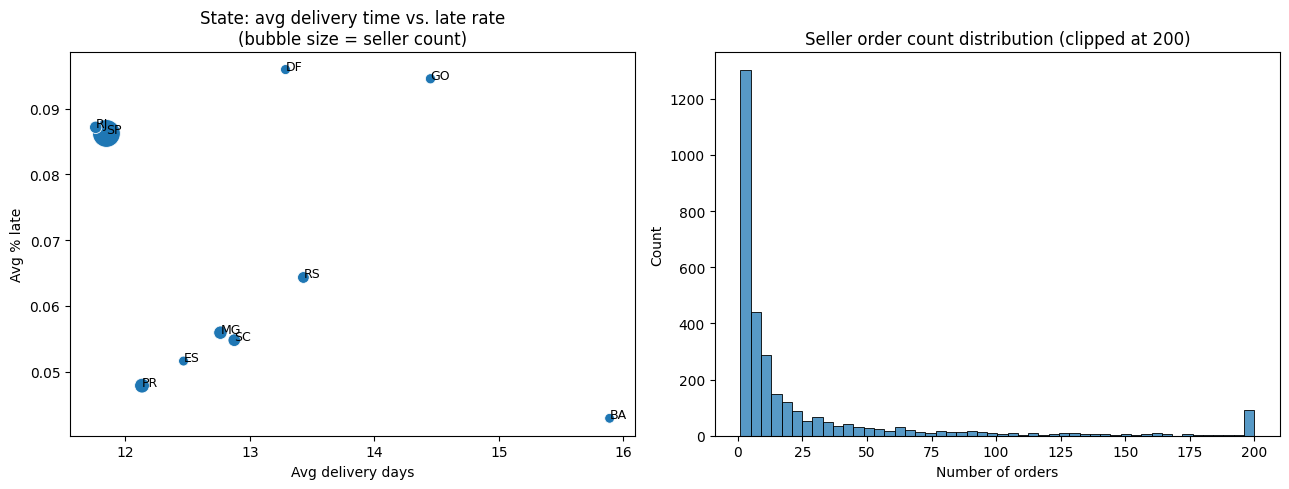

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=state_perf, x='avg_delivery_days', y='avg_pct_late', size='n_sellers',
                 sizes=(50, 400), ax=axes[0], legend=False)
for state, row in state_perf.iterrows():
    axes[0].annotate(state, (row['avg_delivery_days'], row['avg_pct_late']), fontsize=9)
axes[0].set_title('State: avg delivery time vs. late rate\n(bubble size = seller count)')
axes[0].set_xlabel('Avg delivery days')
axes[0].set_ylabel('Avg % late')

sns.histplot(sellers_master['n_orders'].clip(upper=200), bins=50, ax=axes[1])
axes[1].set_title('Seller order count distribution (clipped at 200)')
axes[1].set_xlabel('Number of orders')

plt.tight_layout()
plt.show()

## 6. Some questions to think about

- Small sample sellers: should `sellers_master.csv` carry a `low_confidence` flag (e.g. n_orders < 5) so any chart/dashboard filter can exclude or should we visually de emphasize them by default?

- The BA/SP delivery time vs late rate inversion which is worth checking further now, or wait till Category D's review scores are available to check if it actually matters to customers?

- The 7 sellers with no geolocation match. Whether to leave as null, or backfill with a state level centroid as a fallback so they're not simply missing from any map?


# 7. Enhanced Logistics Analysis

The sections below extend the original Track C analysis above with order level operational details like: seller processing time vs. transportation time, delivery promise gap, fast vs reliable seller profiling, freight burden, geography, timing patterns, and seller concentration.

Every step below adds columns onto a single, progressively built dataframe (`logistics_orders`) rather than repeatedly rebuilding separate
same named tables from scratch.

These are exploratory analyses. They surface patterns worth investigating with Category D's review data.


## 7.0 Optional data for geography based sections

Sections 7.7 to 7.9 need customer location (state, zip) to compare same state vs. cross state delivery and compute seller to customer distance.

These aren't part of Category C's own source files, so we load them only if present, and check once here rather than re checking inconsistently in every cell below.

In [22]:
from pathlib import Path

optional_files = {
    "customers_dataset.csv": "customers",
}

for filename, variable_name in optional_files.items():
    if Path(filename).exists():
        globals()[variable_name] = pd.read_csv(filename)
        print(f"Loaded {filename}: {globals()[variable_name].shape}")
    else:
        print(f"Optional file not found: {filename} -> sections 7.7-7.9 will be skipped.")

has_customer_data = 'customers' in globals()
print("\nhas_customer_data:", has_customer_data)

Loaded customers_dataset.csv: (99441, 5)

has_customer_data: True


## 7.1 Build an order level logistics table

The original Track C analysis aggregates straight to seller level. But seller level averages hide real variation as a seller might perform well for nearby customers and poorly for distant ones.So keeping an order level table first preserves that detail for later sections.

In [25]:
order_seller = (
    items[['order_id', 'seller_id', 'price', 'freight_value']]
    .groupby(['order_id', 'seller_id'], as_index=False)
    .agg(
        order_item_value=('price', 'sum'),
        freight_value=('freight_value', 'sum'),
        n_items=('price', 'size')
    )
)

logistics_orders = order_seller.merge(
    orders_master, on='order_id', how='left', validate='many_to_one'
)

print("Order level logistics shape:", logistics_orders.shape)
print("\nUnique orders:", logistics_orders['order_id'].nunique())
print("Unique sellers:", logistics_orders['seller_id'].nunique())


Order level logistics shape: (100010, 25)

Unique orders: 98666
Unique sellers: 3095


In [26]:
logistics_orders = logistics_orders.merge(
    sellers[['seller_id', 'seller_state']], on='seller_id', how='left'
)

logistics_orders.head()

,order_id,seller_id,order_item_value,freight_value,n_items,customer_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,estimated_delivery_ts,approval_hours,carrier_handoff_days,delivery_days,delivery_delay_days,is_delivered,is_canceled,is_late,total_payment_value,payment_type_primary,max_installments,n_payment_rows,purchase_month,is_split_payment,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,58.90,13.29,1,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,0.775833,6.367141,7.614421,-8.011250,True,False,False,72.19,credit_card,2.0,1.0,2017-09,False,SP
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,1,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,0.201944,8.145683,16.216181,-2.330278,True,False,False,259.83,credit_card,3.0,1.0,2017-04,False,SP
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,199.00,17.87,1,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,0.249722,1.908542,7.948437,-13.444954,True,False,False,216.87,credit_card,5.0,1.0,2018-01,False,MG
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,1,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,0.161944,2.137292,6.147269,-5.435660,True,False,False,25.78,credit_card,2.0,1.0,2018-08,False,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,199.90,18.14,1,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,0.206111,11.816620,25.114352,-15.303808,True,False,False,218.04,credit_card,3.0,1.0,2017-02,False,PR


## 7.2 Decompose delivery into seller processing time and transportation time

Total delivery time alone doesn't say where a delay comes from. Splitting it into two stages lets us tell a seller side story apart from a transportation story:
- **Processing time** = purchase -> carrier handoff (seller's speed)
- **Transport time** = carrier handoff -> delivery (logistics network's speed)


In [27]:
date_cols = ['purchase_ts', 'approved_ts', 'carrier_ts', 'delivered_ts', 'estimated_delivery_ts']
for col in date_cols:
    logistics_orders[col] = pd.to_datetime(logistics_orders[col], errors='coerce')

logistics_orders['processing_days'] = (
    logistics_orders['carrier_ts'] - logistics_orders['purchase_ts']
).dt.total_seconds() / 86400

logistics_orders['transport_days'] = (
    logistics_orders['delivered_ts'] - logistics_orders['carrier_ts']
).dt.total_seconds() / 86400

logistics_orders['delivery_days_calc'] = (
    logistics_orders['delivered_ts'] - logistics_orders['purchase_ts']
).dt.total_seconds() / 86400

logistics_orders[['processing_days', 'transport_days', 'delivery_days_calc']].describe()

,processing_days,transport_days,delivery_days_calc
count,99000.000000,97816.000000,97817.000000
mean,3.221516,9.295676,12.511527
std,3.595517,8.727417,9.511862
min,-171.212419,-16.096169,0.533414
25%,1.126160,4.089476,6.735185
50%,2.198883,7.090457,10.187882
75%,4.059829,12.005949,15.624282
max,125.775521,205.190972,209.628611


In [28]:
# Check for suspicious timing values before relying on these columns further.
for col in ['processing_days', 'transport_days', 'delivery_days_calc']:
    negative = (logistics_orders[col] < 0).sum()
    print(f"{col}: {negative:,} negative values")


processing_days: 176 negative values
transport_days: 42 negative values
delivery_days_calc: 0 negative values


**Finding:** 176 orders show negative processing time and 42 show negative transport time which is the same class of timestamp ordering quirk that Category A had already documented (carrier handoff logged
before approval, in 1.4% of orders).

## 7.3 Delivery promise gap and delay severity

The variable that matters most for Category D isn't simply was this order slow but it is that did it arrive later than promised. So we are building readable delay bands, and separately measure the magnitude of earliness/lateness.

In [29]:
def delay_band(x):
    if pd.isna(x):
        return 'Unknown'
    if x <= -3:
        return '3+ days early'
    if x < 0:
        return '1-2 days early'
    if x == 0:
        return 'On time'
    if x <= 2:
        return '1-2 days late'
    if x <= 7:
        return '3-7 days late'
    return '8+ days late'

logistics_orders['delay_band'] = logistics_orders['delivery_delay_days'].apply(delay_band)

delay_summary = (
    logistics_orders['delay_band'].value_counts(dropna=False)
    .rename_axis('delay_band').reset_index(name='orders')
)
delay_summary['pct_orders'] = 100 * delay_summary['orders'] / len(logistics_orders)
delay_summary

,delay_band,orders,pct_orders
0,3+ days early,85209,85.200480
1,1-2 days early,4763,4.762524
2,8+ days late,3348,3.347665
3,3-7 days late,2373,2.372763
4,Unknown,2193,2.192781
5,1-2 days late,2124,2.123788


In [30]:
logistics_orders['days_early'] = (-logistics_orders['delivery_delay_days']).clip(lower=0)
logistics_orders['days_late'] = logistics_orders['delivery_delay_days'].clip(lower=0)

avg_early = logistics_orders.loc[logistics_orders['delivery_delay_days'] < 0, 'days_early'].mean()
avg_late = logistics_orders.loc[logistics_orders['delivery_delay_days'] > 0, 'days_late'].mean()

print(f"Average days early among early deliveries: {avg_early:.2f}")
print(f"Average days late among late deliveries: {avg_late:.2f}")
print(f"Median delivery delay: {logistics_orders['delivery_delay_days'].median():.2f}")

Average days early among early deliveries: 13.07
Average days late among late deliveries: 9.54
Median delivery delay: -12.02


**Finding:** consistent with Category A/D's original numbers (median delay is 12 days).

- Among orders that are late, the average overshoot is a substantial 9.5 days and not just barely crossing the threshold.

- So worth carrying `delay_band` (not just the continuous value or the binary
`is_late`) into the shared output, since it's a ready made ordinal grouping for charts.

## 7.4 Fast vs. reliable sellers

A seller can be fast but unpredictable, or slow but consistent and the average delivery time alone doesn't distinguish these. So we are building a richer seller level table and plot speed against reliability directly.

In [31]:
seller_enriched = logistics_orders.groupby('seller_id').agg(
    seller_state=('seller_state', 'first'),
    n_orders=('order_id', 'nunique'),
    avg_processing_days=('processing_days', 'mean'),
    median_processing_days=('processing_days', 'median'),
    avg_transport_days=('transport_days', 'mean'),
    median_transport_days=('transport_days', 'median'),
    avg_delivery_days=('delivery_days_calc', 'mean'),
    median_delivery_days=('delivery_days_calc', 'median'),
    avg_delivery_delay=('delivery_delay_days', 'mean'),
    median_delivery_delay=('delivery_delay_days', 'median'),
    pct_late=('is_late', 'mean'),
    pct_early=('delivery_delay_days', lambda s: (s < 0).mean()),
    pct_on_time=('delivery_delay_days', lambda s: (s == 0).mean()),
    avg_freight=('freight_value', 'mean'),
    avg_order_value=('order_item_value', 'mean')
).reset_index()

seller_enriched['freight_ratio'] = seller_enriched['avg_freight'] / seller_enriched['avg_order_value']
seller_enriched['low_confidence'] = seller_enriched['n_orders'] < 5

seller_enriched.head()

,seller_id,seller_state,n_orders,avg_processing_days,median_processing_days,avg_transport_days,median_transport_days,avg_delivery_days,median_delivery_days,avg_delivery_delay,median_delivery_delay,pct_late,pct_early,pct_on_time,avg_freight,avg_order_value,freight_ratio,low_confidence
0,0015a82c2db000af6aaaf3ae2ecb0532,SP,3,3.360590,2.733310,7.433295,7.190995,10.793885,10.747014,-15.593380,-12.301331,0.000000,1.000000,0.0,21.020000,895.000000,0.023486,True
1,001cca7ae9ae17fb1caed9dfb1094831,ES,200,2.592995,2.104618,10.807805,8.191829,13.405805,11.160208,-12.225614,-13.291690,0.065000,0.910000,0.0,44.270700,125.400150,0.353035,False
2,001e6ad469a905060d959994f1b41e4f,RJ,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,17.940000,250.000000,0.071760,True
3,002100f778ceb8431b7a1020ff7ab48f,SP,51,4.421546,3.342720,11.975598,9.947176,16.386809,13.947975,-7.389838,-8.722789,0.176471,0.803922,0.0,15.561961,24.205882,0.642900,False
4,003554e2dce176b5555353e4f3555ac8,GO,1,0.536563,0.536563,4.110243,4.110243,4.646806,4.646806,-26.066794,-26.066794,0.000000,1.000000,0.0,19.380000,120.000000,0.161500,True


Sellers included in reliable comparison: 1793


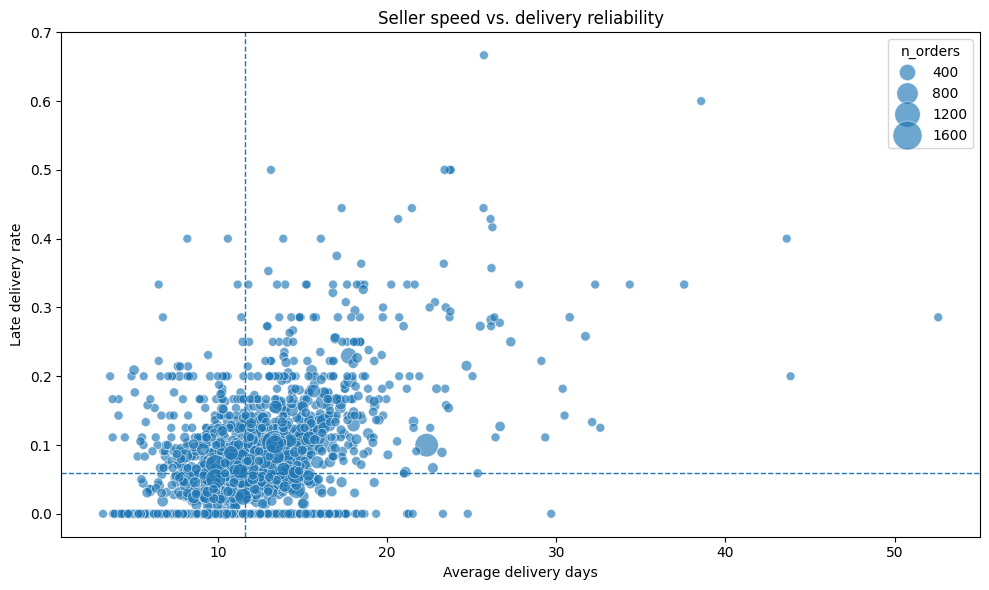

In [33]:
plot_sellers = seller_enriched[seller_enriched['n_orders'] >= 5].dropna(
    subset=['avg_delivery_days', 'pct_late']
).copy()
print("Sellers included in reliable comparison:", len(plot_sellers))

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_sellers, x='avg_delivery_days', y='pct_late',
    size='n_orders', sizes=(40, 500), alpha=0.65, ax=ax
)
ax.axvline(plot_sellers['avg_delivery_days'].median(), linestyle='--', linewidth=1)
ax.axhline(plot_sellers['pct_late'].median(), linestyle='--', linewidth=1)
ax.set_title('Seller speed vs. delivery reliability')
ax.set_xlabel('Average delivery days')
ax.set_ylabel('Late delivery rate')
plt.tight_layout()
plt.show()


**Finding:** here lower left = fast and reliable and upper left = fast but unreliable, similarly lower right = slower but reliable and upper right = slower and unreliable.

- These are exploratory quadrants, not objective good/bad labels so worth reading alongside seller volume (marker size) and category/customer expectations before drawing conclusions.

## 7.5 Does seller size predict performance, continuously?

The original Category C analysis found late rate flat across 4 seller size buckets. Testing this continuously (log scaled) checks whether a threshold effect was hidden by dividing into buckets.

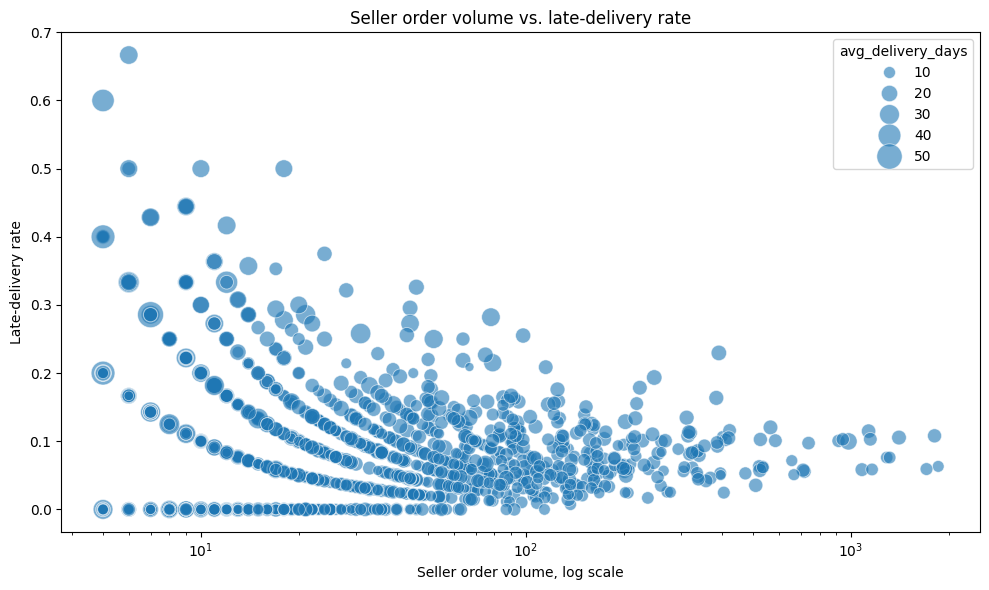

Correlation, log seller volume vs late rate: -0.0015


In [34]:
size_analysis = seller_enriched[
    (seller_enriched['n_orders'] >= 5) & seller_enriched['pct_late'].notna()
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=size_analysis, x='n_orders', y='pct_late',
    size='avg_delivery_days', sizes=(30, 350), alpha=0.6, ax=ax
)
ax.set_xscale('log')
ax.set_title('Seller order volume vs. late-delivery rate')
ax.set_xlabel('Seller order volume, log scale')
ax.set_ylabel('Late-delivery rate')
plt.tight_layout()
plt.show()

corr = size_analysis['n_orders'].clip(lower=1).apply('log').corr(size_analysis['pct_late'])
print(f"Correlation, log seller volume vs late rate: {corr:.4f}")

**Finding:** correlation is essentially zero (−0.0015).

- This confirms the original bucketed finding wasn't hiding a real trend behind the boundaries and seller size genuinely doesn't predict lateness, checked two different ways now.

## 7.6 Freight burden

Absolute freight cost is hard to compare across orders of very different value. Freight as a proportion of order value is more comparable, and opens a few future questions: does freight burden relate to delivery speed, lateness, or (once Category D's data is joined) review score?

In [35]:
logistics_orders['freight_ratio'] = (
    logistics_orders['freight_value'] / logistics_orders['order_item_value'].replace(0, pd.NA)
)
logistics_orders['freight_ratio'].describe(percentiles=[.5, .75, .9, .95, .99])

,freight_ratio
count,100010.000000
mean,0.309707
std,0.328390
min,0.000000
50%,0.224374
75%,0.382196
90%,0.627136
95%,0.843719
99%,1.480537
max,26.235294


In [36]:
freight_bins = pd.qcut(logistics_orders['freight_ratio'], q=5, duplicates='drop')

freight_perf = logistics_orders.groupby(freight_bins, observed=True).agg(
    orders=('order_id', 'nunique'),
    avg_delivery_days=('delivery_days_calc', 'mean'),
    pct_late=('is_late', 'mean'),
    avg_delay=('delivery_delay_days', 'mean')
).reset_index()

freight_perf

,freight_ratio,orders,avg_delivery_days,pct_late,avg_delay
0,"(-0.001, 0.114]",19935,11.468998,0.079042,-10.907107
1,"(0.114, 0.182]",19971,11.967361,0.076385,-10.959315
2,"(0.182, 0.273]",19932,12.323512,0.074548,-11.214140
3,"(0.273, 0.436]",19950,13.069449,0.081576,-11.229568
4,"(0.436, 26.235]",19896,13.720283,0.080658,-11.949270


**Finding:** late rate is nearly flat across freightratio quintiles (7.5% to 8.2%). This is another factor that can be stated as ruled out, similar shape to payment type (Track A) and seller size (above).

## 7.7 Same state vs. cross state delivery

Once customer location is available, comparing deliveries within the seller's own state against deliveries crossing a state boundary is a simple, interpretable geographic feature.

**Note:** this and the next two sections keep adding columns onto `logistics_orders` directly, rather than branching into a separately named copy so `seller_state` (already present) and everything added here stays available to every later section.

In [37]:
if has_customer_data:
    customer_state = customers[['customer_id', 'customer_state']].drop_duplicates('customer_id')
    logistics_orders = logistics_orders.merge(customer_state, on='customer_id', how='left')
    logistics_orders['same_state'] = logistics_orders['seller_state'] == logistics_orders['customer_state']

    state_route_perf = logistics_orders.groupby('same_state').agg(
        orders=('order_id', 'nunique'),
        avg_delivery_days=('delivery_days_calc', 'mean'),
        avg_processing_days=('processing_days', 'mean'),
        avg_transport_days=('transport_days', 'mean'),
        pct_late=('is_late', 'mean'),
        avg_delay=('delivery_delay_days', 'mean')
    ).reset_index()

    print(state_route_perf)
else:
    print("Customer data not available. Same-state analysis skipped.")


   same_state  orders  avg_delivery_days  avg_processing_days  avg_transport_days  pct_late  avg_delay
0       False   63313          15.089733             3.273007           11.824431  0.089556 -12.119185
1        True   35600           7.921714             3.129408            4.793969  0.058647  -9.709352


**Finding:** same state deliveries average 7.9 days and cross state average 15.1 days which is nearly double. Late rate is also close to double for cross state orders (8.96% vs. 5.86%). This was kind of expected but now it is proven, and it is a strong candidate for a same state/cross state comparison chart.

## 7.8 Seller to customer distance

With both seller and customer coordinates available, we can compute an approximate straight line (haversine) distance which is not actual road distance, but a geographic proxy. It will be useful for checking
distance -> transport time, distance -> lateness, and later, distance -> review score as well. Tested with bins rather than assuming a linear relationship.

In [38]:
if has_customer_data:
    customer_geo = customers[['customer_id', 'customer_zip_code_prefix']].drop_duplicates('customer_id')
    customer_geo = customer_geo.merge(
        geo_agg, left_on='customer_zip_code_prefix', right_on='zip_code_prefix', how='left'
    )

    logistics_orders = logistics_orders.merge(
        customer_geo[['customer_id', 'lat', 'lng']], on='customer_id', how='left'
    )

    seller_coords = sellers_master[['seller_id', 'lat', 'lng']].rename(
        columns={'lat': 'seller_lat', 'lng': 'seller_lng'}
    )
    logistics_orders = logistics_orders.merge(seller_coords, on='seller_id', how='left')

    import numpy as np
    lat1, lon1 = np.radians(logistics_orders['seller_lat']), np.radians(logistics_orders['seller_lng'])
    lat2, lon2 = np.radians(logistics_orders['lat']), np.radians(logistics_orders['lng'])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    logistics_orders['distance_km'] = 6371 * 2 * np.arcsin(np.sqrt(a))

    print(logistics_orders['distance_km'].describe())
else:
    print("Customer data not available. Distance analysis skipped.")


count    99510.000000
mean       600.786724
std        592.827887
min          0.000000
25%        186.365096
50%        433.752700
75%        798.489086
max       3579.339684
Name: distance_km, dtype: float64


In [39]:
if has_customer_data and 'distance_km' in logistics_orders.columns:
    distance_analysis = logistics_orders.dropna(subset=['distance_km']).copy()
    distance_bins = pd.qcut(distance_analysis['distance_km'], q=6, duplicates='drop')

    distance_perf = distance_analysis.groupby(distance_bins, observed=True).agg(
        orders=('order_id', 'nunique'),
        avg_distance_km=('distance_km', 'mean'),
        avg_transport_days=('transport_days', 'mean'),
        avg_delivery_days=('delivery_days_calc', 'mean'),
        pct_late=('is_late', 'mean'),
        avg_delay=('delivery_delay_days', 'mean')
    ).reset_index()

    print(distance_perf.to_string())
else:
    print("Distance table unavailable.")


          distance_km  orders  avg_distance_km  avg_transport_days  avg_delivery_days  pct_late  avg_delay
0     (-0.001, 85.44]   16502        33.850659            3.242494           6.368412  0.060959  -8.921005
1    (85.44, 305.601]   16467       192.617857            6.561054           9.719816  0.063129 -10.646125
2  (305.601, 433.753]   16470       362.461211            9.172966          12.325371  0.074525 -11.783880
3  (433.753, 626.464]   16478       517.890552            9.777763          13.013869  0.076617 -11.766526
4  (626.464, 963.646]   16461       790.440978           11.412428          14.677588  0.082926 -12.188229
5  (963.646, 3579.34]   16451      1707.524818           15.553376          18.919883  0.111788 -12.246254


**Finding:** mean distance is 601 km, max is 3,579 km and both are geographically possible for Brazil.

## 7.9 Seller state and destination state performance

State level averages can hide large differences between specific routes. For sellers with enough observations, seller to destination state combinations can reveal a seller that's reliable locally but weak on long distance routes, or a destination region that's difficult across many
sellers. Only combinations with enough orders are kept.

In [40]:
if has_customer_data and 'customer_state' in logistics_orders.columns:
    route_perf = logistics_orders.groupby(
        ['seller_id', 'seller_state', 'customer_state'], dropna=False
    ).agg(
        n_orders=('order_id', 'nunique'),
        avg_delivery_days=('delivery_days_calc', 'mean'),
        avg_processing_days=('processing_days', 'mean'),
        avg_transport_days=('transport_days', 'mean'),
        pct_late=('is_late', 'mean'),
        avg_delay=('delivery_delay_days', 'mean'),
        avg_freight=('freight_value', 'mean')
    ).reset_index()

    route_perf_reliable = route_perf[route_perf['n_orders'] >= 10].copy()
    print("Seller-destination routes with >=10 orders:", len(route_perf_reliable))

    print(route_perf_reliable.sort_values(['pct_late', 'n_orders'], ascending=[False, False]).head(20).to_string())
else:
    print("Customer-state data unavailable. Route analysis skipped.")


Seller-destination routes with >=10 orders: 1916
                              seller_id seller_state customer_state  n_orders  avg_delivery_days  avg_processing_days  avg_transport_days  pct_late  avg_delay  avg_freight
3213   2c9e548be18521d1c43cde1c582c6de8           SP             RJ        16          34.963365             2.533733           32.429632  0.625000   9.982504    19.480000
9328   835f0f7810c76831d6c7d24c7a646d4d           SP             SP        13          14.405934            11.003738            3.402196  0.615385  -0.329362    11.693077
12123  b1b3948701c5c72445495bd161b83a4c           SP             SP        10          19.087626            14.665000            4.422626  0.600000   4.134510    27.067000
544    06a2c3af7b3aee5d69171b0e14f0ee87           MA             ES        13          28.534771             7.759080           20.775691  0.538462  -1.674602    28.496923
14099  cd68562d3f44870c08922d380acae552           SP             RJ        10          21.5

## 7.10 Temporal delivery patterns

Delivery performance might change with workload or seasonality. Calendar features let us check
for monthly trends, weekday effects on seller processing, and whether weekend orders take longer
to reach the carrier.

In [41]:
logistics_orders['purchase_month'] = logistics_orders['purchase_ts'].dt.to_period('M').astype(str)
logistics_orders['purchase_weekday'] = logistics_orders['purchase_ts'].dt.day_name()

monthly_perf = logistics_orders.groupby('purchase_month').agg(
    orders=('order_id', 'nunique'),
    avg_processing_days=('processing_days', 'mean'),
    avg_transport_days=('transport_days', 'mean'),
    avg_delivery_days=('delivery_days_calc', 'mean'),
    pct_late=('is_late', 'mean'),
    avg_delay=('delivery_delay_days', 'mean')
).reset_index()

monthly_perf.tail(15)

,purchase_month,orders,avg_processing_days,avg_transport_days,avg_delivery_days,pct_late,avg_delay
9,2017-07,3969,3.123185,8.406337,11.529628,0.032945,-11.798794
10,2017-08,4293,3.081659,7.998236,11.070810,0.032162,-12.423848
11,2017-09,4243,3.181323,8.632407,11.820062,0.050361,-10.626300
12,2017-10,4568,3.428894,8.370428,11.800541,0.051111,-11.217047
13,2017-11,7451,4.055268,11.060512,15.108814,0.138580,-7.463043
14,2017-12,5624,3.714843,11.659872,15.365401,0.081780,-12.324326
15,2018-01,7220,3.577001,10.454082,14.028480,0.063276,-12.299766
16,2018-02,6694,3.553080,13.354399,16.906034,0.155796,-7.622595
17,2018-03,7188,3.318977,12.919999,16.239177,0.206153,-5.833654
18,2018-04,6934,2.814298,8.633209,11.445832,0.051068,-12.277630


In [42]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_perf = logistics_orders.groupby('purchase_weekday').agg(
    orders=('order_id', 'nunique'),
    avg_processing_days=('processing_days', 'mean'),
    avg_delivery_days=('delivery_days_calc', 'mean'),
    pct_late=('is_late', 'mean'),
    avg_delay=('delivery_delay_days', 'mean')
).reindex(weekday_order).reset_index()

weekday_perf

,purchase_weekday,orders,avg_processing_days,avg_delivery_days,pct_late,avg_delay
0,Monday,16068,2.701336,11.953143,0.087552,-10.671328
1,Tuesday,15831,2.832361,12.035103,0.082200,-11.051029
2,Wednesday,15425,2.983317,12.396694,0.075572,-11.262176
3,Thursday,14639,3.363205,12.699479,0.073255,-11.386151
4,Friday,14002,4.202880,13.526361,0.081578,-11.062885
5,Saturday,10813,3.865491,13.317701,0.073359,-11.870502
6,Sunday,11888,2.833448,11.891358,0.072196,-11.786162


**Finding:** processing time rises toward the end of the week (Friday 4.2 days vs Monday 2.7 days) maybe a weekend handoff delays.

## 7.11 Order concentration

A small number of sellers might handle a large share of marketplace orders and if so, overall delivery performance depends heavily on a relatively small group.

Cumulative order share by seller, checked at the top 10, top 50, and top 10% marks.

In [43]:
seller_volume = (
    seller_enriched[['seller_id', 'n_orders']].dropna()
    .sort_values('n_orders', ascending=False).reset_index(drop=True)
)
seller_volume['cumulative_orders'] = seller_volume['n_orders'].cumsum()
seller_volume['cumulative_order_share'] = seller_volume['cumulative_orders'] / seller_volume['n_orders'].sum()

n_sellers = len(seller_volume)
for n in [10, 50, max(1, int(n_sellers * 0.10))]:
    n = min(n, n_sellers)
    share = seller_volume.loc[n - 1, 'cumulative_order_share']
    print(f"Top {n:,} sellers handle {share:.1%} of seller attributed orders.")


Top 10 sellers handle 13.9% of seller attributed orders.
Top 50 sellers handle 33.5% of seller attributed orders.
Top 309 sellers handle 68.4% of seller attributed orders.


**Finding:** the top 10% of sellers (309 of 3,095) handle 68.4% of all orders. So the marketplace delivery performance is disproportionately determined by a small group which is directly relevant to
leadership's where to invest/intervene question, since improving a small number of high volume sellers would have more impact.

## 7.12 State level variation, not just state averages

The original state analysis (Section 5) averages sellers within each state. An average can hide whether performance is consistent across sellers or driven by a few outliers. This computes the spread (median, quartiles, IQR) of seller level late rates within each state which is a strong candidate
for a boxplot chart.

In [44]:
state_distribution = (
    seller_enriched.dropna(subset=['seller_state', 'pct_late'])
    .groupby('seller_state')
    .agg(
        n_sellers=('seller_id', 'nunique'),
        median_late=('pct_late', 'median'),
        q25_late=('pct_late', lambda s: s.quantile(.25)),
        q75_late=('pct_late', lambda s: s.quantile(.75)),
        avg_late=('pct_late', 'mean')
    ).reset_index()
)
state_distribution['iqr_late'] = state_distribution['q75_late'] - state_distribution['q25_late']

state_distribution.sort_values('median_late', ascending=False).head(15)

,seller_state,n_sellers,median_late,q25_late,q75_late,avg_late,iqr_late
1,AM,1,0.666667,0.666667,0.666667,0.666667,0.000000
7,MA,1,0.229592,0.229592,0.229592,0.229592,0.000000
11,PA,1,0.125000,0.125000,0.125000,0.125000,0.000000
10,MT,4,0.031481,0.013889,0.054167,0.036574,0.040278
4,DF,30,0.030952,0.000000,0.118750,0.095964,0.118750
2,BA,19,0.000000,0.000000,0.048727,0.042880,0.048727
0,AC,1,0.000000,0.000000,0.000000,0.000000,0.000000
6,GO,40,0.000000,0.000000,0.035575,0.094563,0.035575
5,ES,23,0.000000,0.000000,0.032500,0.051592,0.032500
3,CE,13,0.000000,0.000000,0.090909,0.125761,0.090909


**Finding:** several states have only 1 seller (`n_sellers = 1`), which makes IQR trivially
zero which is a reminder that the same small sample caution from the seller level applies at the state level too when using this table.

## 7.13 Save the enhanced seller-level output

Keeping the original `sellers_master.csv` intact and creating a second, enhanced file instead, so nothing already depending on the original schema breaks.

In [45]:
sellers_master_enhanced = sellers_master.drop(
    columns=['n_orders', 'avg_delivery_days', 'pct_late', 'avg_freight_value'], errors='ignore'
).merge(
    seller_enriched.drop(columns=['seller_state', 'low_confidence'], errors='ignore'),
    on='seller_id', how='left'
)

sellers_master_enhanced.to_csv('sellers_master_enhanced.csv', index=False)
print("Saved sellers_master_enhanced.csv:", sellers_master_enhanced.shape)

Saved sellers_master_enhanced.csv: (3095, 22)


## 7.14 Save the order level logistics table

The most broadly useful new output is one row per order seller pair, ready to hand to Category D (join on `order_id` for review score) and Category E (integration into `analysis_master.csv`).

In [46]:
order_logistics_columns = [
    'order_id', 'seller_id', 'customer_id', 'seller_state', 'order_status',
    'purchase_ts', 'approved_ts', 'carrier_ts', 'delivered_ts', 'estimated_delivery_ts',
    'processing_days', 'transport_days', 'delivery_days_calc', 'delivery_delay_days',
    'days_early', 'days_late', 'delay_band', 'is_delivered', 'is_late',
    'order_item_value', 'freight_value', 'freight_ratio', 'n_items',
    'purchase_month', 'purchase_weekday',
    'customer_state', 'same_state', 'distance_km',   # present only if customer data was loaded
]

order_logistics_master = logistics_orders[
    [c for c in order_logistics_columns if c in logistics_orders.columns]
].copy()

order_logistics_master.to_csv('order_logistics_master.csv', index=False)
print("Saved order_logistics_master.csv:", order_logistics_master.shape)
order_logistics_master.head()

Saved order_logistics_master.csv: (100010, 28)


,order_id,seller_id,customer_id,seller_state,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,estimated_delivery_ts,processing_days,transport_days,delivery_days_calc,delivery_delay_days,days_early,days_late,delay_band,is_delivered,is_late,order_item_value,freight_value,freight_ratio,n_items,purchase_month,purchase_weekday,customer_state,same_state,distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,SP,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,6.399468,1.214954,7.614421,-8.011250,8.011250,0.0,3+ days early,True,False,58.90,13.29,0.225637,1,2017-09,Wednesday,RJ,False,301.229205
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,SP,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,8.154097,8.062083,16.216181,-2.330278,2.330278,0.0,1-2 days early,True,False,239.90,19.93,0.083076,1,2017-04,Wednesday,SP,True,588.404069
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,MG,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1.918947,6.029491,7.948437,-13.444954,13.444954,0.0,3+ days early,True,False,199.00,17.87,0.089799,1,2018-01,Sunday,MG,True,312.835023
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,SP,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2.144039,4.003229,6.147269,-5.435660,5.435660,0.0,3+ days early,True,False,12.99,12.79,0.984604,1,2018-08,Wednesday,SP,True,295.032480
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,PR,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,11.825208,13.289144,25.114352,-15.303808,15.303808,0.0,3+ days early,True,False,199.90,18.14,0.090745,1,2017-02,Saturday,SP,False,646.468544


## 7.15 Some findings to check with Category D

1. Does review score decline as delivery delay increases?
2. Is being late more important than being slow?
3. Does seller processing time predict review score independently of transport time?
4. Does distance affect reviews through delivery time?
5. Does freight burden relate to satisfaction?
6. Are cross state deliveries less reliable, and does that show up in reviews?
7. Do high volume sellers have different customer satisfaction?
8. Are there threshold effects, where reviews fall sharply after a certain delay?
9. Are particular seller and destination routes unusually unreliable?
10. Does the BA/SP inversion from Section 5 appear in review scores too?

The strongest future visualizations should answer these with clear comparisons.

## 7.16 Recommended visualization candidates

**First Priority:**
- Fast vs. reliable seller quadrant
- Delivery delay band vs. review score
- Processing time vs. transport time
- Delivery delay vs. review score
- Distance band vs. late rate
- State seller late rate distributions (boxplot)

**Second Priority:**
- Freight ratio vs. late rate
- Seller size vs. reliability
- Seller and destination state heatmap
- Monthly late rate trend
- Same state vs. cross state comparison
